In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import OrderedDict
from torch.utils.data import TensorDataset, DataLoader,Dataset
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm


%matplotlib ipympl

In [2]:
#TODO: Fix LSP: https://github.com/jupyter-lsp/jupyterlab-lsp

In [3]:
DATA_PATH = os.path.join("..", "data", "crop-recommendation-dataset",
                         "Crop_recommendation.parquet.gzip")
RANDOM_STATE = 42

# Context
Precision agriculture is in trend nowadays. It helps the farmers to get informed decision about the farming strategy. Here, I present you a dataset which would allow the users to build a predictive model to recommend the most suitable crops to grow in a particular farm based on various parameters.

## Context
This dataset was build by augmenting datasets of rainfall, climate and fertilizer data available for India.

## Data fields
N - ratio of Nitrogen content in soil

P - ratio of Phosphorous content in soil

K - ratio of Potassium content in soil

temperature - temperature in degree Celsius

humidity - relative humidity in %

ph - ph value of the soil

rainfall - rainfall in mm

In [36]:
# data = pd.read_parquet(DATA_PATH)
# # label = data.pop('label')
# data_columns = data.columns
# data_index = data.index
# data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [72]:
# os.path.dirname(DATA_PATH)

'../data/crop-recommendation-dataset'

In [32]:
DATA_LABELS = ['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee']

In [40]:
# le = LabelEncoder()
# le.fit(DATA_LABELS)
# set(le.transform(data["label"]))

In [32]:
# import pyarrow.parquet as pq
# for batch in pq.ParquetFile(DATA_PATH).iter_batches(1):
#     columns = batch.column_names
#     label = columns.pop()
#     # yield self.dataScaler.transform(batch.to_tensor().to_numpy())
#     # label = table.drop(['col_B'])
#     print( batch.select(columns).to_tensor().to_numpy(),
#            batch.select([label]).to_pandas().to_numpy())
#     break

[[ 90.          42.          43.          20.87974371  82.00274423
    6.50298529 202.9355362 ]] [['rice']]


In [17]:
# data.to_parquet('Crop_recommendation.parquet.gzip',compression='gzip')

In [22]:
# print(f"{len(label.unique()) = }\n")
# label.head()

len(label.unique()) = 22



0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: object

In [35]:
# # Data has no NAN
# data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


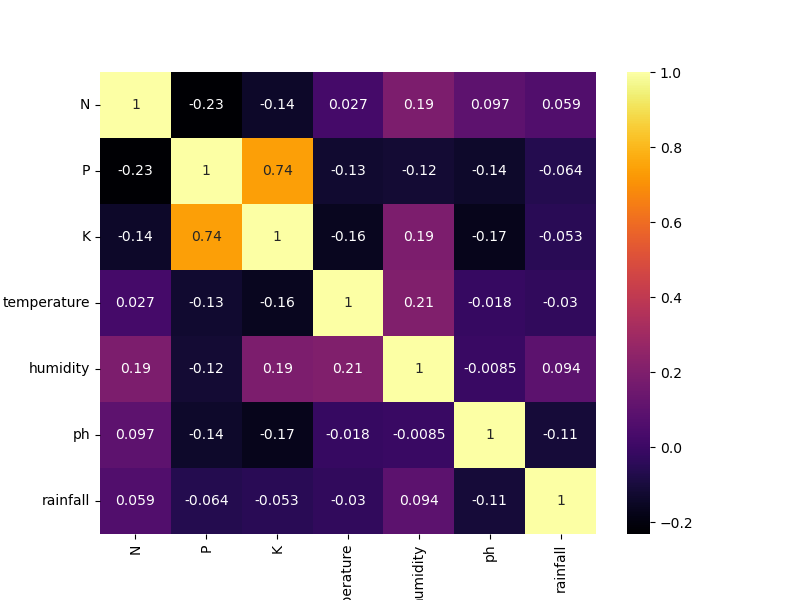

In [23]:
# corr_matrix = data.corr()
# filtered_corr_df = corr_matrix

# plt.figure(figsize=(8, 6))
# sns.heatmap(filtered_corr_df, annot=True, cmap="inferno")
# plt.show()

# # We could try apply a PCA to keep only 2 to 3 axis

# Pre-processing

## Data split with PCA


We will, for now, use all components

In [24]:
# scaler = StandardScaler()
# data = data.to_numpy()
# scaler.fit(data)

# pca = PCA(n_components=data.shape[1])
# pca.fit(data)
# data = pca.transform(data)

# X_train, X_test, y_train, y_test = train_test_split(data, label,
#                                                     test_size = 0.20,
#                                                     random_state = RANDOM_STATE,
#                                                     shuffle=True)

# X_train = scaler.transform(X_train)
# X_test = scaler.transform(X_test)

# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
#                                                     test_size = 0.10,
#                                                     random_state = RANDOM_STATE,
#                                                   shuffle=True)

# print(f"Train size: {X_train.size}\nVal size: {X_val.size}\nTest size: {X_test.size}")

Train size: 11088
Val size: 1232
Test size: 3080


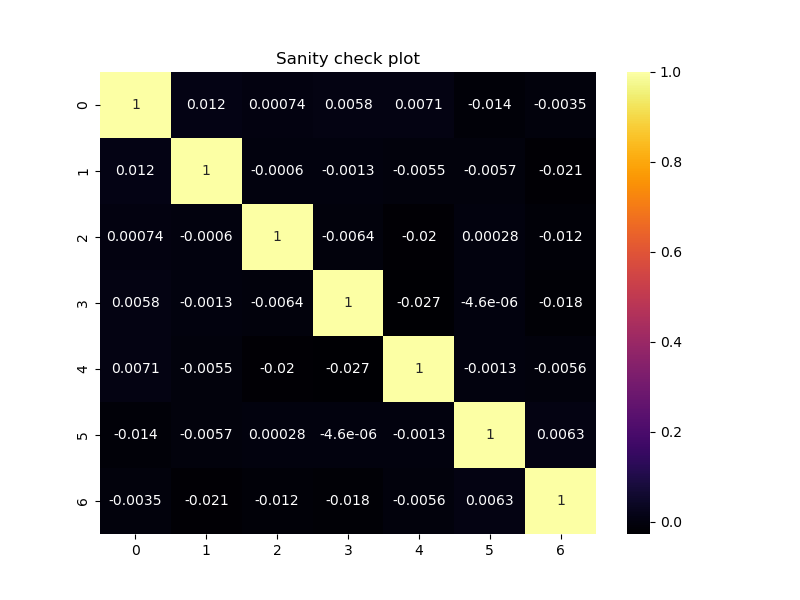

In [26]:
# size_samples = X_train.shape[0]
# filtered_corr_df = (pd.DataFrame(data=X_train[:size_samples])).corr()
# plt.figure(figsize=(8, 6))
# sns.heatmap(filtered_corr_df, annot=True, cmap="inferno")
# plt.title("Sanity check plot")
# plt.show()

# Torch Objects

# Model

In [4]:
class CropClassifier(nn.Module):
    def __init__(self) -> None:
        super(CropClassifier, self).__init__()
        self.ff = nn.Sequential(OrderedDict([
            ('inputLayer', nn.Linear(7, 32)),
            ('activationFunction1', nn.Tanh()),
            ('linear_Hidden1', nn.Linear(32, 2)),
            ('activationFunction3', nn.Tanh()),
            ('linear_Hidden3', nn.Linear(2, 16)),
            ('activationFunction4', nn.Tanh()),
            ('linear_Hidden4', nn.Linear(16, 22))
        ]))

    def forward(self, x):
        # return nn.Softmax(self.ff(x))
        return self.ff(x)

## Dataloader

### Utils.FileDataset.py

In [105]:
# import pyarrow.parquet as pq
# from pyarrow.parquet import ParquetFile
# import pyarrow as pa

# def _get_parquet_columns( file_path):
#     pf = ParquetFile(file_path)
#     first_ten_rows = next(pf.iter_batches(batch_size=1))
#     return pa.Table.from_batches([first_ten_rows]).to_pandas().columns
# list(_get_parquet_columns(DATA_PATH)).pop()

In [106]:
## Testing logic
# def _get_records_iterator(file_path):
#     # Replace this with logic to iterate over your specific data
#     for batch in pq.ParquetFile(file_path).iter_batches(1):
#         yield batch.to_pandas().to_numpy(),batch.to_pandas().to_numpy()[0]
# iterator1 = _get_records_iterator(DATA_PATH)
# a,b = next(iterator1)
# print(a)
# print("\n\n")
# print(b)

In [5]:
from torch.utils.data import IterableDataset, get_worker_info
import pyarrow.parquet as pq
from pathlib import Path
import pyarrow as pa


# https://apxml.com/courses/advanced-pytorch/chapter-3-optimization-training-strategies/large-dataset-strategies
class FileDataset(IterableDataset):
    def __init__(self, file_path, label_encoder, normalizer):
        super().__init__()
        if (Path(file_path).suffix == '.parquet' or
                Path(file_path).suffix == '.parquet.gzip'):
            raise ValueError("The input file shoud be a '.parquet.gzip' or \
            '.parquet.gzip'.")
        self.file_path = file_path
        fileColumns = self._get_parquet_columns(file_path)
        self.label = fileColumns.pop()
        self.columns = fileColumns
        self.labelEncoder = label_encoder
        self.normalizer = normalizer

    def _get_records_iterator(self):
        # Replace this with logic to iterate over your specific data
        for batch in pq.ParquetFile(self.file_path).iter_batches(1):
            yield (batch.select(self.columns).to_tensor().to_numpy(),
                   batch.select([self.label]).to_pandas().to_numpy())

    def __iter__(self):
        worker_info = get_worker_info()
        record_iterator, label = zip(*self._get_records_iterator())
        if worker_info is None:  # Single-process loading
            worker_id = 0
            num_workers = 1
        else:  # Multi-process loading
            worker_id = worker_info.id
            num_workers = worker_info.num_workers

        # Basic worker sharding: each worker processes every Nth record
        # Sophisticated sharding might involve byte offsets or file splitting
        sharded_iterator = ((self.normalizer.transform(record),
                             self.labelEncoder.transform(label[i][0])
                             ) for i, record in enumerate(record_iterator)
                            if i % num_workers == worker_id)

        # Apply processing within the worker's iterator chain
        # processed_iterator = map(self.processor_fn, sharded_iterator)
        return sharded_iterator

    def _get_parquet_columns(self, file_path: str) -> list:
        pf = pq.ParquetFile(file_path)
        first_ten_rows = next(pf.iter_batches(batch_size=1))
        return list(pa.Table.from_batches([first_ten_rows]).to_pandas().columns)

In [6]:
from enum import Enum

class DatasetType(Enum):
    TRAIN = "train"
    VAL = "val"
    TEST = "test"

In [7]:
class ProcessData:
    def __init__(self, data_path: str, data_labels: list = None,
                 label_column="label"):
        # TODO: Change label_column parameter value to **kargs
        # TODO: Add this labels to a config file
        self.data_path = data_path
        self.data_labels = ['rice', 'maize', 'chickpea', 'kidneybeans',
                            'pigeonpeas', 'mothbeans', 'mungbean', 'blackgram',
                            'lentil', 'pomegranate', 'banana', 'mango', 'grapes',
                            'watermelon', 'muskmelon', 'apple', 'orange', 'papaya',
                            'coconut', 'cotton', 'jute', 'coffee']
        self._generate_label_encoder()
        self._generate_data_normalizer(data_path)

    def _generate_label_encoder(self):
        self.lebel_encoder = LabelEncoder()
        self.lebel_encoder.fit(self.data_labels)

    def _generate_data_normalizer(self, data_path: str,
                                  label_column="label"):
        self.data_normalizer = StandardScaler()
        data = pd.read_parquet(data_path)
        data.pop(label_column)
        self.data_normalizer.fit(data.to_numpy())

    def split_and_shuffle_data(self, label_column='label',
                               test_size=0.2,
                               val_size=0.1,
                               RANDOM_STATE=42):
        file_name = os.path.basename(self.data_path)
        dir_path = os.path.dirname(self.data_path)
        data = pd.read_parquet(self.data_path)
        # Shuffle data
        data = data.sample(frac=1).reset_index(drop=True)
        data_train, data_test = train_test_split(data,
                                                 test_size=test_size,
                                                 random_state=RANDOM_STATE,
                                                 shuffle=True)
        data_train, data_val = train_test_split(data_train,
                                                test_size=val_size,
                                                random_state=RANDOM_STATE,
                                                shuffle=True)
        try:
            data_test.to_parquet(os.path.join(dir_path,
                                              f'{DatasetType.TEST.value}_{file_name}'),
                                 compression='gzip')
            data_val.to_parquet(os.path.join(dir_path,
                                             f'{DatasetType.VAL.value}_{file_name}'),
                                compression='gzip')
            data_train.to_parquet(os.path.join(dir_path,
                                               f'{DatasetType.TRAIN.value}_{file_name}'),
                                  compression='gzip')
        except Exception as e:
            raise TypeError(f"Could not write one of the split file. {str(e)}")

    def get_enum_dataset(self, dataset_type: str):
        dir_path = os.path.dirname(self.data_path)
        file_name = os.path.basename(self.data_path)
        validated_type = DatasetType(dataset_type.lower())
        # TODO: If the current file do not exist, add a try-except to execute
        # split_and_shuffle_data and retrieve the data
        if (validated_type == DatasetType.TRAIN):
            file_path = os.path.join(dir_path,
                                     f'{DatasetType.TRAIN.value}_{file_name}')
            return FileDataset(file_path, self.lebel_encoder,
                               self.data_normalizer)
        if (validated_type == DatasetType.VAL):
            file_path = os.path.join(dir_path,
                                     f'{DatasetType.VAL.value}_{file_name}')
            return FileDataset(file_path, self.lebel_encoder,
                               self.data_normalizer)
        if (validated_type == DatasetType.TEST):
            file_path = os.path.join(dir_path,
                                     f'{DatasetType.TEST.value}_{file_name}')
            return FileDataset(file_path, self.lebel_encoder,
                               self.data_normalizer)
        raise ValueError(f"The current type {dataset_type} do not exist.\
        Please, run the split_and_shuffle_data before calling this method.")



In [20]:
from torcheval.metrics.functional import multiclass_precision

class Trainer:
    def __init__(self, model, data_processer: ProcessData,
                 batch_size=64):
        # self.training_set = training_set
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model = model.to(self.device)
        self.data_processer = data_processer
        self.model_results = {"loss": [],
                              "vloss": [],
                              "epoch": [],
                             "vmulticlass_precision":[]}
        self.batch_size = batch_size
        self.loss_function = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.AdamW(self.model.parameters(),
                                          lr=0.01)
        self.epochs = 100
        # Saves the training results
        self.woking_dir = None
        self.DEBUG = False

    def _generate_dataloader(self, dataset_type: DatasetType):
        """Given the numpy array, gnerate the train and val dataloader"""
        file_dataset = self.data_processer.get_enum_dataset(dataset_type.value)
        return DataLoader(file_dataset,
                          batch_size=self.batch_size,
                          pin_memory=True)

    def train_epoch(self, train_dataloader):
        running_loss = 0.
        last_loss = 0.
        self.model.train(True)

        for index, data in enumerate(train_dataloader):
            inputs, labels = data
            inputs = inputs.to(self.device).float()
            labels = labels.to(self.device).long().squeeze()

            self.optimizer.zero_grad()
            outputs = self.model(inputs)
            # TODO: There is a unity dim on the dataloader. Verify 
            loss = self.loss_function(outputs.squeeze(1),
                                     labels)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            # if i % 1000 == 999:
            last_loss = running_loss / self.batch_size # loss per batch
            #     print('  batch {} loss: {}'.format(i + 1, last_loss))
            #     # tb_x = epoch_index * len(training_loader) + i + 1
            #     # tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            #     running_loss = 0.
        return last_loss

    def validate(self, val_dataloader):
        """Process of validating"""
        running_vloss = 0.0
        running_vPrecision = 0.0
        
        self.model.eval()

        # Disable gradient computation and reduce memory consumption.
        with torch.no_grad():
            for index, vdata in enumerate(val_dataloader):
                vinputs, vlabels = vdata
                vinputs = vinputs.to(self.device).float()
                vlabels = vlabels.to(self.device).long().squeeze()
                voutputs = self.model(vinputs)
                running_vPrecision += multiclass_precision(voutputs.squeeze(1),
                                                           vlabels,
                                                           average="weighted",
                                                           num_classes=len(self.data_processer.data_labels))
                vloss = self.loss_function(voutputs.squeeze(1),
                                           vlabels)
                running_vloss += vloss.item()
        self.model_results["vmulticlass_precision"].append(running_vPrecision / (index+1))
        return running_vloss / (index + 1)

    def run(self):
        """Execute train and val steps"""
        # Initializing in a separate cell so we can easily add more epochs to the same run
        # TODO: Enable this Writer
        # timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        # writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
        epoch_number = 0
        best_vloss = 99e99
        train_dataloader = self._generate_dataloader(DatasetType.TRAIN)
        val_dataloader = self._generate_dataloader(DatasetType.VAL)

        for epoch in tqdm(range(self.epochs)):

            # Make sure gradient tracking is on, and do a pass over the data
            avg_loss = self.train_epoch(train_dataloader)
            avg_vloss = self.validate(val_dataloader)
            self.model_results["loss"].append(avg_loss)
            self.model_results["vloss"].append(avg_vloss)
            self.model_results["epoch"].append(epoch_number)
            
            # # Log the running loss averaged per batch
            # # for both training and validation
            # writer.add_scalars('Training vs. Validation Loss',
            #                 { 'Training' : avg_loss, 'Validation' : avg_vloss },
            #                 epoch_number + 1)
            # writer.flush()
            if self.DEBUG:
                break
            epoch_number += 1

In [21]:
data_processer = ProcessData(DATA_PATH)
model = CropClassifier()
trainer = Trainer(model, data_processer)

In [22]:
trainer.run()

100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [01:22<00:00,  1.21it/s]


In [23]:
import matplotlib.pyplot as plt

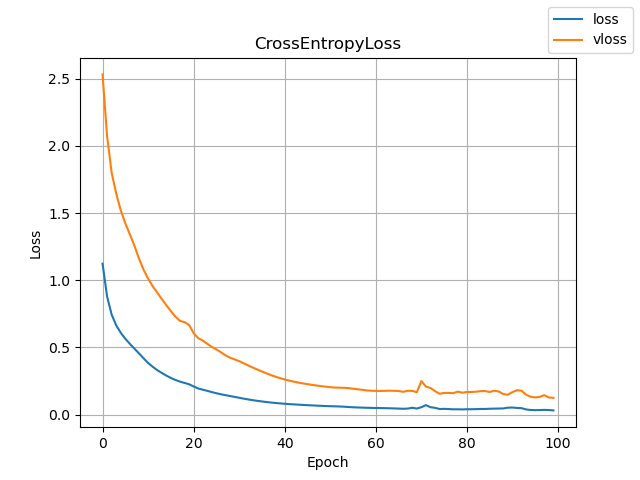

In [24]:
fig, ax = plt.subplots()

ax.plot(trainer.model_results["epoch"],
       trainer.model_results["loss"], label="loss")
ax.plot(trainer.model_results["epoch"],
       trainer.model_results["vloss"], label="vloss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
fig.legend()
ax.grid()
ax.set_title("CrossEntropyLoss")
plt.show()

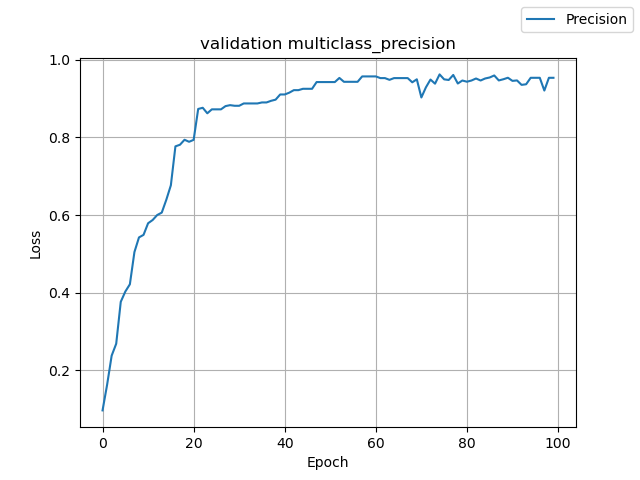

In [29]:
fig, ax = plt.subplots()
values = [a.item() for a in trainer.model_results["vmulticlass_precision"]]
ax.plot(trainer.model_results["epoch"],
       values, label="Precision")


ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
fig.legend()
ax.grid()
ax.set_title("validation multiclass_precision")
plt.show()